# A/B Compartment analysis


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import os

import cooler
import cooltools
import cooltools.lib.plotting
import bioframe
from packaging import version

if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("cooltools >= 0.5.4 required")

In [ ]:
DATA_DIR = "./Hi-c"
OUT_DIR = os.path.join(DATA_DIR, "analysis", "compartment")
os.makedirs(OUT_DIR, exist_ok=True)

COOL_FILE = os.path.join(DATA_DIR, "file", "KO", "cool_file", "KO_merged_noXY_1kb_200bin.cool")
print("Cooler:", COOL_FILE)

Cooler: /media/ggj/ggj/CJY/nature_WXY/Hi-c/file/KO/cool_file/KO_merged_noXY_1kb_200bin.cool


In [ ]:
# 1) load cooler
clr = cooler.Cooler(COOL_FILE)
binsize = clr.binsize
print(f"Binsize: {binsize}, Chroms: {list(clr.chromnames)}")

Binsize: 200000, Chroms: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX', 'chrY']


In [ ]:
# ---------- 2) GC content: E1 orientation----------
bins = clr.bins()[:]
GENOME_FASTA = os.environ.get("MM10_FASTA", "/media/ggj/ggj/CJY/tools/mm10/mm10/data/mm10.fa")
genome = bioframe.load_fasta(GENOME_FASTA)
fa_chroms = list(genome.keys())

bins_interval = bins[["chrom", "start", "end"]].copy()
sample_chrom = bins_interval["chrom"].iloc[0]
bins_for_gc = bins_interval.copy()
if sample_chrom not in fa_chroms:
    stripped = bins_interval["chrom"].str.replace("^chr", "", regex=True)
    if stripped.iloc[0] in fa_chroms:
        bins_for_gc["chrom"] = stripped
    else:
        capped = bins_interval["chrom"].str.replace("^chr", "Chr", regex=True)
        if capped.iloc[0] in fa_chroms:
            bins_for_gc["chrom"] = capped
gc_result = bioframe.frac_gc(bins_for_gc, genome)
gc_cov = bins_interval.copy()
gc_cov["GC"] = gc_result["GC"].values

gc_cov.to_csv(os.path.join(OUT_DIR, f"gc_cov_{binsize}.tsv"), index=False, sep="\t")

# NaN porpotion
n_total = len(gc_cov)
n_nan = gc_cov["GC"].isna().sum()
n_ok = n_total - n_nan
print(f"GC 统计: 总 bin 数={n_total}, 有效 GC={n_ok}, NaN={n_nan} ({100*n_nan/n_total:.1f}%)")
print(f"FASTA 染色体名示例: {fa_chroms[:5]}")
if n_nan > 0:
    print("各染色体 NaN 数量:")
    print(gc_cov.groupby("chrom")["GC"].apply(lambda s: s.isna().sum()).to_string())
display(gc_cov.head())

/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


GC 统计: 总 bin 数=13640, 有效 GC=13316, NaN=324 (2.4%)
FASTA 染色体名示例: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5']
各染色体 NaN 数量:
chrom
chr1     16
chr10    17
chr11    16
chr12    15
chr13    16
chr14    15
chr15    16
chr16    16
chr17    15
chr18    15
chr19    16
chr2     15
chr3     16
chr4     16
chr5     17
chr6     16
chr7     16
chr8     16
chr9     15
chrX     18
chrY      6


/tmp/ipykernel_532826/1047712897.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gc_cov.groupby("chrom")["GC"].apply(lambda s: s.isna().sum()).to_string())


,chrom,start,end,GC
0,chr1,0,200000,NaN
1,chr1,200000,400000,NaN
2,chr1,400000,600000,NaN
3,chr1,600000,800000,NaN
4,chr1,800000,1000000,NaN


In [ ]:
# ---------- 3) view_df ----------
view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames,
})
display(view_df.head())

,chrom,start,end,name
0,chr1,0,195471971,chr1
1,chr10,0,130694993,chr10
2,chr11,0,122082543,chr11
3,chr12,0,120129022,chr12
4,chr13,0,120421639,chr13


In [ ]:
# ---------- cis feature ----------
# n_eigs=3 
cis_eigs = cooltools.eigs_cis(
    clr,
    gc_cov,
    view_df=view_df,
    n_eigs=3,
)
# cis_eigs[0]=eigenvalues, cis_eigs[1]=bins contains E1,E2,E3 col
eigenvector_track = cis_eigs[1][["chrom", "start", "end", "E1"]].copy()
eigenvector_track.to_csv(os.path.join(OUT_DIR, f"eigenvector_E1_{binsize}_KO.tsv"), index=False, sep="\t")
print("E1 saved", os.path.join(OUT_DIR, f"eigenvector_E1_{binsize}_KO.tsv"))
display(eigenvector_track.head())

/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


E1 已保存至 /media/ggj/ggj/CJY/nature_WXY/Hi-c/analysis/compartment/eigenvector_E1_200000_KO.tsv


,chrom,start,end,E1
0,chr1,0,200000,NaN
1,chr1,200000,400000,NaN
2,chr1,400000,600000,NaN
3,chr1,600000,800000,NaN
4,chr1,800000,1000000,NaN


In [ ]:
## 5) heatmap + E1 

/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 23460 (\N{CJK UNIFIED IDEOGRAPH-5BA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_532826/3204239519.py:34: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: Use

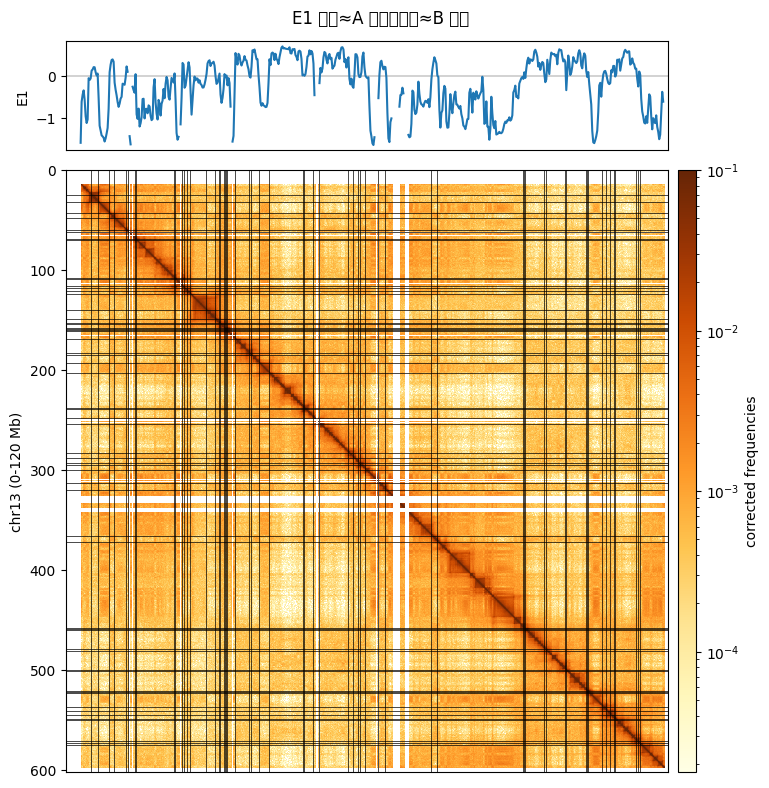

In [ ]:
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

CHROM_VIZ = "chr13" 
region = (CHROM_VIZ, 0, clr.chromsizes[CHROM_VIZ])
matrix_region = clr.matrix(balance=True).fetch(region)
n_bins = matrix_region.shape[0]

f, ax = plt.subplots(figsize=(14, 8))
norm = LogNorm(vmax=0.1)
im = ax.matshow(matrix_region, norm=norm, cmap="YlOrBr")
plt.axis([0, n_bins, n_bins, 0])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(im, cax=cax, label="corrected frequencies")
ax.set_ylabel(f"{CHROM_VIZ} (0-{clr.chromsizes[CHROM_VIZ]//1e6:.0f} Mb)")
ax.xaxis.set_visible(False)

# plot E1 
eig_chr = eigenvector_track[eigenvector_track["chrom"] == CHROM_VIZ]["E1"].values
ax1 = divider.append_axes("top", size="18%", pad=0.2, sharex=ax)
ax1.plot([0, len(eig_chr)], [0, 0], "k", lw=0.25)
ax1.plot(eig_chr, label="E1")
ax1.set_ylabel("E1")
ax1.set_xticks([])

# A/B border
for i in np.where(np.diff((eig_chr > 0).astype(int)))[0]:
    ax.axhline(i, color="k", lw=0.5)
    ax.axvline(i, color="k", lw=0.5)
plt.suptitle(f"E1 正值≈A 区室，负值≈B 区室")
plt.tight_layout()
plt.show()

In [ ]:
# ---------- 6) Cis expected contact ----------
cvd = cooltools.expected_cis(clr=clr, view_df=view_df)

/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [ ]:
# ---------- 7) Saddle args ----------
Q_LO = 0.025   
Q_HI = 0.975   
N_GROUPS = 38  

In [ ]:
# ---------- 8)  Saddle matrix ----------
interaction_sum, interaction_count = cooltools.saddle(
    clr,
    cvd,
    eigenvector_track,
    "cis",
    n_bins=N_GROUPS,
    qrange=(Q_LO, Q_HI),
    view_df=view_df,
)


/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


In [ ]:
## 9) Saddle plot

In [ ]:

import warnings
from functools import partial
try:
    from cytoolz import merge
except ImportError:
    from toolz import merge

def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

#     warnings.warn(
#         "Generating a saddleplot will be deprecated in future versions, "
#         + "please see https://github.com/open2c_examples for examples on how to plot saddles.",
#         DeprecationWarning,
#     )

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
    else:
        print('cbar')

        cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)

    return grid

/home/ggj/anaconda3/envs/py39/lib/python3.9/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/tmp/ipykernel_532826/3754780346.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()


cbar


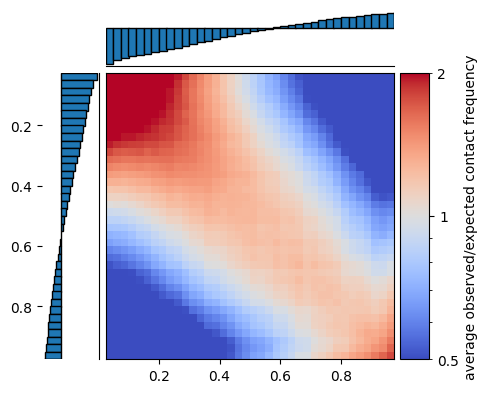

Saddle 图已保存至 /media/ggj/ggj/CJY/nature_WXY/Hi-c/analysis/compartment/saddle_200000_KO.pdf


In [ ]:
# plot Saddle（O/E heatmap）
saddleplot(
    eigenvector_track,
    interaction_sum / interaction_count,
    N_GROUPS,
    qrange=(Q_LO, Q_HI),
    cbar_kws={"label": "average observed/expected contact frequency"},
)
plt.savefig(os.path.join(OUT_DIR, f"saddle_{binsize}_KO.pdf"), bbox_inches="tight")
plt.show()
print("Saddle saved", os.path.join(OUT_DIR, f"saddle_{binsize}_KO.pdf"))

## WT vs KO compartment statistic


In [ ]:

COMPARTMENT_DIR = "./Hi-c/analysis/compartment"
BINSIZE = 200000

e1_wt = pd.read_csv(os.path.join(COMPARTMENT_DIR, f"eigenvector_E1_{BINSIZE}_WT.tsv"), sep="\t")
e1_ko = pd.read_csv(os.path.join(COMPARTMENT_DIR, f"eigenvector_E1_{BINSIZE}_KO.tsv"), sep="\t")
e1_wt["E1"] = pd.to_numeric(e1_wt["E1"], errors="coerce")
e1_ko["E1"] = pd.to_numeric(e1_ko["E1"], errors="coerce")

merge_keys = ["chrom", "start", "end"]
m = e1_wt[merge_keys + ["E1"]].merge(
    e1_ko[merge_keys + ["E1"]], on=merge_keys, suffixes=("_WT", "_KO")
)
m = m.dropna(subset=["E1_WT", "E1_KO"])
n_bins = len(m)

共 11630 个 bin 同时有 WT/KO E1，用于统计。


In [ ]:
# ---------- 1) correlation ----------
from scipy import stats

r_pearson, p_pearson = stats.pearsonr(m["E1_WT"], m["E1_KO"])
r_spearman, p_spearman = stats.spearmanr(m["E1_WT"], m["E1_KO"])

m["comp_WT"] = (m["E1_WT"] > 0).astype(int)  # 1=A, 0=B
m["comp_KO"] = (m["E1_KO"] > 0).astype(int)
agree = (m["comp_WT"] == m["comp_KO"]).sum()
pct_agree = 100 * agree / n_bins
n_switch = n_bins - agree

# Cohen's kappa
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(m["comp_WT"], m["comp_KO"])

per_chrom = []
for chrom, g in m.groupby("chrom"):
    if len(g) < 10:
        continue
    rp, _ = stats.pearsonr(g["E1_WT"], g["E1_KO"])
    rs, _ = stats.spearmanr(g["E1_WT"], g["E1_KO"])
    k = cohen_kappa_score(g["comp_WT"], g["comp_KO"])
    per_chrom.append({"chrom": chrom, "n": len(g), "r_pearson": rp, "r_spearman": rs, "kappa": k})
df_chrom = pd.DataFrame(per_chrom)

summary = {
    "n_bins": n_bins,
    "r_pearson": r_pearson,
    "p_pearson": p_pearson,
    "r_spearman": r_spearman,
    "p_spearman": p_spearman,
    "pct_agree": pct_agree,
    "n_switch": n_switch,
    "kappa": kappa,
}
display(df_chrom.round(4))

【基因组整体】
  Pearson r = 0.9948, p = 0.00e+00
  Spearman r = 0.9951, p = 0.00e+00
  A/B 一致比例 = 97.02%, 发生区室转换的 bin 数 = 346
  Cohen's kappa = 0.9401


,chrom,n,r_pearson,r_spearman,kappa
0,chr1,954,0.9942,0.9945,0.9266
1,chr10,622,0.9941,0.9934,0.9256
2,chr11,590,0.9963,0.9958,0.9492
3,chr12,549,0.9957,0.9956,0.9258
4,chr13,560,0.9927,0.9927,0.8943
5,chr14,557,0.9948,0.9946,0.9240
6,chr15,498,0.9942,0.9938,0.9298
7,chr16,474,0.9940,0.9931,0.9255
8,chr17,443,0.9952,0.9956,0.9593
9,chr18,435,0.9934,0.9934,0.9350


In [ ]:
# ---------- 2) test ----------

n_perm = 2000
r_perm = []
np.random.seed(42)
e1_ko_shuf = m["E1_KO"].values.copy()
for _ in range(n_perm):
    np.random.shuffle(e1_ko_shuf)
    r_perm.append(np.corrcoef(m["E1_WT"].values, e1_ko_shuf)[0, 1])
r_perm = np.array(r_perm)
# two sides p：|r_perm| >= |r_obs| porpotion
p_perm = (np.abs(r_perm) >= np.abs(r_pearson)).mean()

置换检验 (n=2000): 观测 r = 0.9948, p_perm = 0.0000
结论: WT 与 KO 的区室信号（E1）存在显著相关，即两条件区室整体一致。


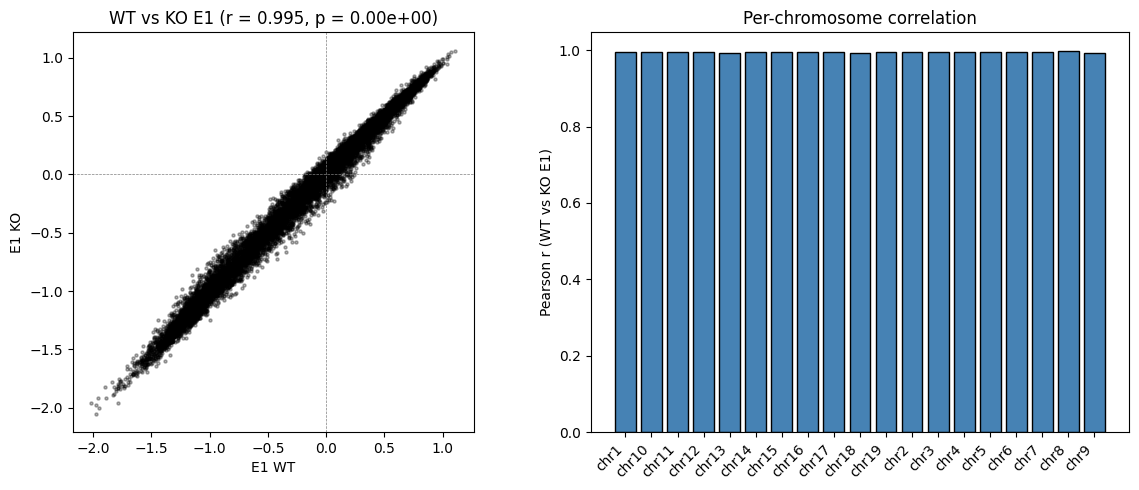

图已保存至 /media/ggj/ggj/CJY/nature_WXY/Hi-c/analysis/compartment/WT_KO_compartment_stats.pdf


In [ ]:
# ---------- 3) save ----------
f, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(m["E1_WT"], m["E1_KO"], alpha=0.3, s=5, c="k")
ax.set_xlabel("E1 WT")
ax.set_ylabel("E1 KO")
ax.set_title(f"WT vs KO E1 (r = {r_pearson:.3f}, p = {p_pearson:.2e})")
ax.axhline(0, color="gray", ls="--", lw=0.5)
ax.axvline(0, color="gray", ls="--", lw=0.5)
ax.set_aspect("equal")

ax = axes[1]
x = range(len(df_chrom))
ax.bar(x, df_chrom["r_pearson"].values, color="steelblue", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(df_chrom["chrom"].values, rotation=45, ha="right")
ax.axhline(0, color="gray", ls="-", lw=0.5)
ax.set_ylabel("Pearson r (WT vs KO E1)")
ax.set_title("Per-chromosome correlation")
plt.tight_layout()
plt.savefig(os.path.join(COMPARTMENT_DIR, "WT_KO_compartment_stats.pdf"), bbox_inches="tight")
plt.show()
print("saved", os.path.join(COMPARTMENT_DIR, "WT_KO_compartment_stats.pdf"))

In [ ]:

pd.DataFrame([summary]).to_csv(
    os.path.join(COMPARTMENT_DIR, "WT_KO_compartment_summary.tsv"), sep="\t", index=False
)
df_chrom.to_csv(os.path.join(COMPARTMENT_DIR, "WT_KO_compartment_per_chrom.tsv"), sep="\t", index=False)
print("saved: WT_KO_compartment_summary.tsv, WT_KO_compartment_per_chrom.tsv")